<a href="https://colab.research.google.com/github/AidanSaeed/AI-Studio-/blob/main/Demand_Forecasting_for_Ad_Spend_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Forecasting for Ad Spend Planning

In [ ]:
!pip install vaderSentiment xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.0 MB/s eta 0:00:00


Import libraries


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Load Dataset

In [ ]:
#Load Dataset
df = pd.read_csv('y_amazon-google-large.csv')
df

,Unnamed: 0,ds,y,unique_id
0,0,2020-01-01 08:00:00,6.0,0
1,1,2020-01-01 09:00:00,0.0,0
2,2,2020-01-01 10:00:00,4.0,0
3,3,2020-01-01 11:00:00,8.0,0
4,4,2020-01-01 12:00:00,4.0,0
...,...,...,...,...
3054995,7826773,2021-06-25 19:00:00,6.0,238
3054996,7826774,2021-06-25 20:00:00,21.0,238
3054997,7826775,2021-06-25 21:00:00,11.0,238
3054998,7826776,2021-06-25 22:00:00,11.0,238


In [ ]:
# Convert date column into a proper datetime format so that it can be sorted and analysed as a time series
df['ds'] = pd.to_datetime(df['ds'], format='mixed')
#print date range and number of series
print('Number of series:', df['unique_id'].nunique())
print('Date range:', df['ds'].min(), 'to', df['ds'].max())
df.head()

Number of series: 235
Date range: 2020-01-01 08:00:00 to 2021-06-25 23:00:00


,Unnamed: 0,ds,y,unique_id
0,0,2020-01-01 08:00:00,6.0,0
1,1,2020-01-01 09:00:00,0.0,0
2,2,2020-01-01 10:00:00,4.0,0
3,3,2020-01-01 11:00:00,8.0,0
4,4,2020-01-01 12:00:00,4.0,0


chose one time serie to use as an example (Series 0) and order its observations highlighting a simple example for examining the demand pattern before modelling all series.

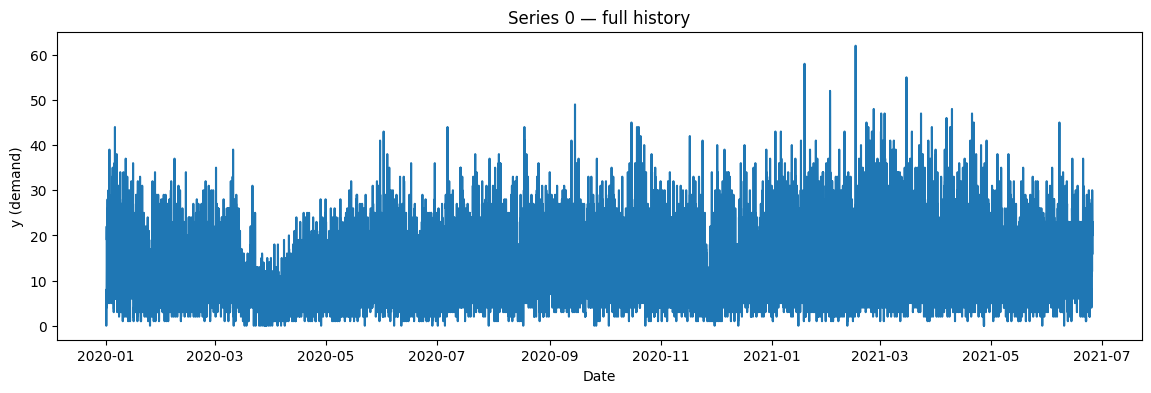

In [ ]:
# Plot the graph of the history of Series 0 to visualise overall demand behaviour
series_0 = df[df['unique_id'] == 0].sort_values('ds')

plt.figure(figsize=(14, 4))
plt.plot(series_0['ds'], series_0['y'])
plt.title('Series 0 — full history')
plt.xlabel('Date')
plt.ylabel('y (demand)')
plt.show()

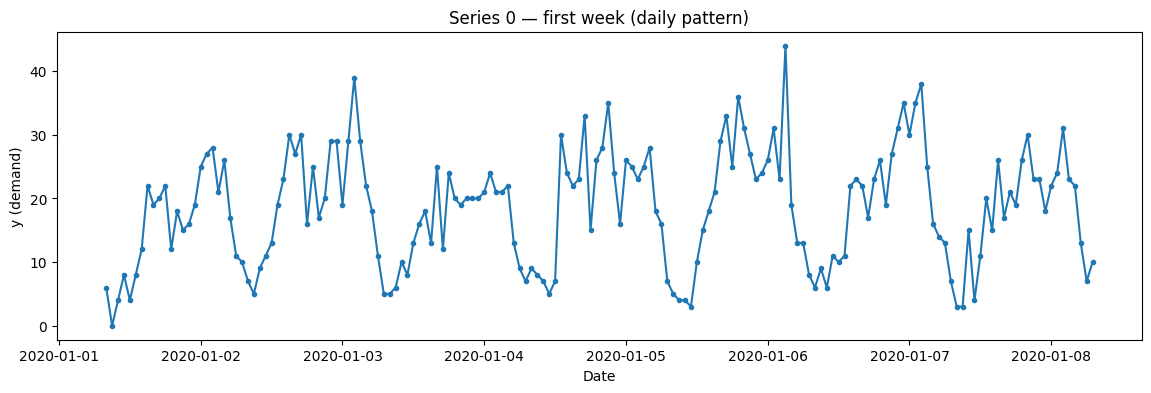

In [ ]:
# plot the first seven days of Series 0 to check the short-term(24-hour) demand pattern.
one_week = series_0[series_0['ds'] < series_0['ds'].min() + pd.Timedelta(days=7)]
plt.figure(figsize=(14, 4))
plt.plot(one_week['ds'], one_week['y'], marker='o', markersize=3)
plt.title('Series 0 — first week (daily pattern)')
plt.xlabel('Date')
plt.ylabel('y (demand)')
plt.show()

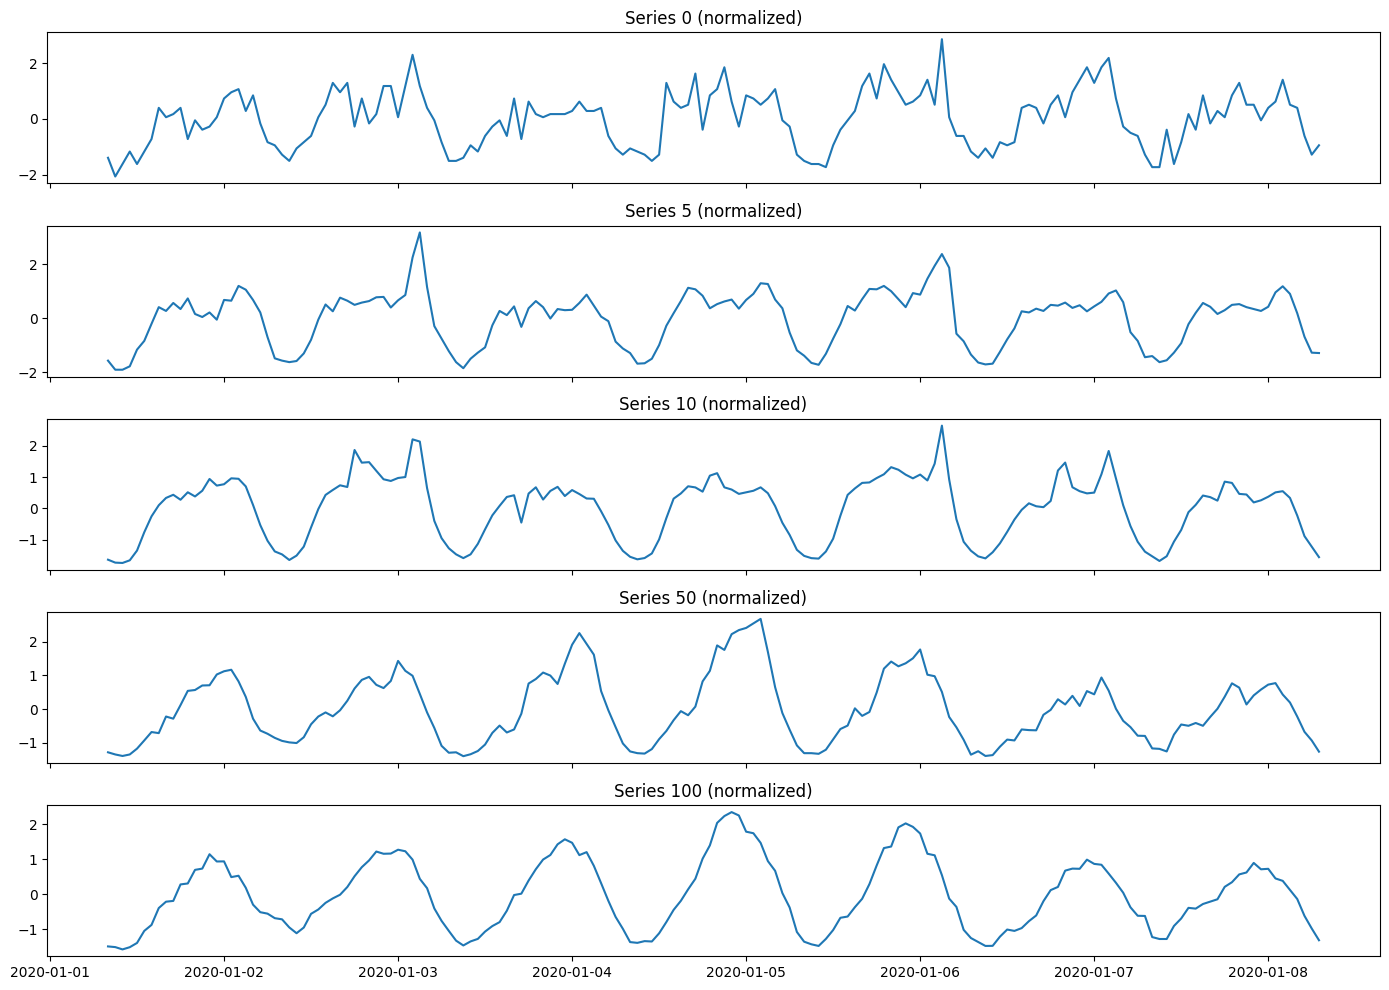

In [ ]:
 # pick five representative time series for exploratory analysis and comparison with the statistical baseline.
sample_ids = [0, 5, 10, 50, 100]

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(14, 10), sharex=True)

for ax, uid in zip(axes, sample_ids):
    s = df[df['unique_id'] == uid].sort_values('ds')
    one_week = s[s['ds'] < s['ds'].min() + pd.Timedelta(days=7)]

    normalized = (one_week['y'] - one_week['y'].mean()) / one_week['y'].std()
    ax.plot(one_week['ds'], normalized)
    ax.set_title(f'Series {uid} (normalized)')
# Plot selected series after normalisation
plt.tight_layout()
plt.show()

# Train/test Split

Create a train/test split(chronological order) by using the final 14 days as the test period thus respecting the structure of time-series and avoiding using future observations to train the model.

In [ ]:

cutoff_date = df['ds'].max() - pd.Timedelta(days=14)

train = df[df['ds'] <= cutoff_date].copy()
test = df[df['ds'] > cutoff_date].copy()

print('Train range:', train['ds'].min(), 'to', train['ds'].max())
print('Test range:', test['ds'].min(), 'to', test['ds'].max())
print('Train rows:', len(train), ' Test rows:', len(test))

Train range: 2020-01-01 08:00:00 to 2021-06-11 23:00:00
Test range: 2021-06-12 00:00:00 to 2021-06-25 23:00:00
Train rows: 2976040  Test rows: 78960


Scaling
Helps the LSTM train more efficiently while preventing data leakage

In [ ]:
from sklearn.preprocessing import StandardScaler
# Standardise demand separately for each time series.
scalers = {}
train_scaled_list = []
test_scaled_list = []
# Scale each series individually using only its training observations to prevent information from leaking from the test period into preprocessing.
for uid in df['unique_id'].unique():
    train_series = train[train['unique_id'] == uid].copy()
    test_series = test[test['unique_id'] == uid].copy()

    if not train_series.empty:
        scaler = StandardScaler()
        train_series['y_scaled'] = scaler.fit_transform(train_series[['y']])
        scalers[uid] = scaler
        train_scaled_list.append(train_series)


        if not test_series.empty:
            test_series['y_scaled'] = scaler.transform(test_series[['y']])
            test_scaled_list.append(test_series)

train_scaled = pd.concat(train_scaled_list).reset_index(drop=True)
test_scaled = pd.concat(test_scaled_list).reset_index(drop=True)

print(train_scaled[['unique_id', 'ds', 'y', 'y_scaled']].head())

   unique_id                  ds    y  y_scaled
0          0 2020-01-01 08:00:00  6.0 -1.095858
1          0 2020-01-01 09:00:00  0.0 -1.812627
2          0 2020-01-01 10:00:00  4.0 -1.334781
3          0 2020-01-01 11:00:00  8.0 -0.856935
4          0 2020-01-01 12:00:00  4.0 -1.334781


Sequence Creation

since the dataset is hourly, we count 24 observations to represents a full day of demand

In [ ]:
#Defining the number of previous observations used to predict the next observation.
LOOKBACK = 24

def create_sequences(values, lookback=LOOKBACK):
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback])
    return np.array(X), np.array(y)

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
test_meta = []



Data Preparation(LSTM)

In [ ]:
def create_sequences(values, lookback=LOOKBACK):
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback])
    X = np.array(X)
    y = np.array(y)

    if X.ndim == 1 and X.size == 0:
        X = X.reshape(0, lookback)
    return X, y

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
test_meta = []
# create and test sequences for each time series while preserving chronological order.
for uid in df['unique_id'].unique():
    train_vals = train_scaled[train_scaled['unique_id'] == uid]['y_scaled'].values
    test_series = test_scaled[test_scaled['unique_id'] == uid]

    if len(train_vals) >= LOOKBACK + 1:
        X_tr, y_tr = create_sequences(train_vals)
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)

    bridge_vals = np.concatenate([train_vals[-LOOKBACK:], test_series['y_scaled'].values])


    if len(bridge_vals) >= LOOKBACK + 1:
        X_te, y_te = create_sequences(bridge_vals)
        X_test_list.append(X_te)
        y_test_list.append(y_te)

        test_meta.append(test_series[['unique_id', 'ds']].iloc[LOOKBACK - LOOKBACK:].reset_index(drop=True))

X_train_seq = np.concatenate(X_train_list)[..., np.newaxis] if X_train_list else np.empty((0, LOOKBACK, 1))
y_train_seq = np.concatenate(y_train_list) if y_train_list else np.empty(0)
X_test_seq = np.concatenate(X_test_list)[..., np.newaxis] if X_test_list else np.empty((0, LOOKBACK, 1))
y_test_seq = np.concatenate(y_test_list) if y_test_list else np.empty(0)

print('X_train_seq shape:', X_train_seq.shape)
print('X_test_seq shape:', X_test_seq.shape)

X_train_seq shape: (2970400, 24, 1)
X_test_seq shape: (78960, 24, 1)


Train the LSTM model

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Configure the LSTM training process with Adam optimisation using mean squared error as the loss function.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split as tts

lstm_model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

X_tr, X_val, y_tr, y_val = tts(X_train_seq, y_train_seq, test_size=0.1, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=256,
    callbacks=[early_stop], verbose=1,
)

Epoch 1/10
10443/10443 ━━━━━━━━━━━━━━━━━━━━ 324s 31ms/step - loss: 0.0754 - mae: 0.1772 - val_loss: 0.0649 - val_mae: 0.1669
Epoch 2/10
10443/10443 ━━━━━━━━━━━━━━━━━━━━ 367s 35ms/step - loss: 0.0641 - mae: 0.1608 - val_loss: 0.0778 - val_mae: 0.1976
Epoch 3/10
10443/10443 ━━━━━━━━━━━━━━━━━━━━ 377s 36ms/step - loss: 0.0617 - mae: 0.1571 - val_loss: 0.0796 - val_mae: 0.1960
Epoch 4/10
10443/10443 ━━━━━━━━━━━━━━━━━━━━ 281s 27ms/step - loss: 0.0603 - mae: 0.1551 - val_loss: 0.0852 - val_mae: 0.2036


Evaluate the trained LSTM on the test sequences

In [ ]:
lstm_model.evaluate(X_test_seq, y_test_seq)

2468/2468 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0232 - mae: 0.0907


[0.02315848506987095, 0.09070055186748505]

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 5.7 MB/s eta 0:00:00


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Fit Holt-Winters model to each of the five selected series using only the training period

for uid in sample_ids:
    train_vals = train[train['unique_id'] == uid].sort_values('ds')['y'].values
    test_vals = test[test['unique_id'] == uid].sort_values('ds')['y'].values

    model = ExponentialSmoothing(
        train_vals, trend='add', seasonal='add', seasonal_periods=24
    ).fit()
    forecast = model.forecast(len(test_vals))

    hw_results[uid] = {'y_true': test_vals, 'y_pred': forecast}
    print(f'Series {uid}: fitted')

Series 0: fitted
Series 5: fitted
Series 10: fitted
Series 50: fitted
Series 100: fitted


Evaluate and compare LSTM and Holt-Winters forecast performance using the average MAE, RMSE, and MAPE across the five selected series

In [ ]:
import gc
import tensorflow as tf
tf.keras.backend.clear_session()
#evaluate model
def evaluate_series(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.nanmean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

lstm_metrics = {}
# Generates LSTM forecasts for the same five series used by Holt-Winters ensuring that both models are evaluated on identical test periods.
for uid in sample_ids:
    train_vals_scaled = train_scaled[train_scaled['unique_id'] == uid]['y_scaled'].values
    test_series = test_scaled[test_scaled['unique_id'] == uid]

    bridge_vals = np.concatenate([train_vals_scaled[-LOOKBACK:], test_series['y_scaled'].values])
    X_te, y_te = create_sequences(bridge_vals)
    X_te = X_te[..., np.newaxis]

    y_pred_scaled = lstm_model.predict(X_te, verbose=0).flatten()

    scaler = scalers[uid]
    y_pred_real = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true_real = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

    lstm_metrics[uid] = evaluate_series(y_true_real, y_pred_real)

hw_metrics = {uid: evaluate_series(res['y_true'], res['y_pred']) for uid, res in hw_results.items()}
#Convert the results to tables and calculate the average performance across the five selected series.

lstm_df = pd.DataFrame(lstm_metrics).T
hw_df = pd.DataFrame(hw_metrics).T

comparison = pd.DataFrame({
    'Holt-Winters': hw_df.mean(),
    'LSTM': lstm_df.mean(),
})
print(comparison)

      Holt-Winters        LSTM
MAE      47.726704   36.195354
RMSE     63.292098   52.447247
MAPE    161.274151  178.178207


Visualise the LSTM predictions against the actual demand values to display how closely the model followed the demand pattern.

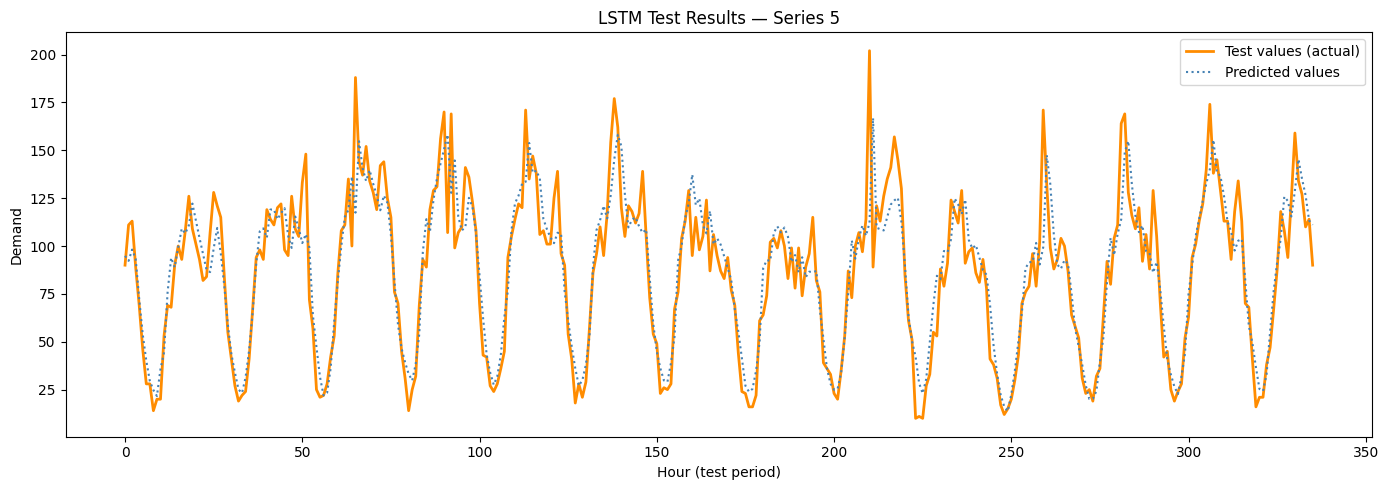

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Plot the test demand against the LSTM predictions for any series (Series 5).
    train_vals = train_scaled[train_scaled['unique_id'] == series_id]['y_scaled'].values
    test_vals = test_scaled[test_scaled['unique_id'] == series_id]['y_scaled'].values

    context = train_vals[-LOOKBACK:]
    full_seq = np.concatenate([context, test_vals])

    X_s, y_s = create_sequences(full_seq, LOOKBACK)
    X_s = X_s[..., np.newaxis]

    preds_scaled = lstm_model.predict(X_s, verbose=0).flatten()

    scaler = scalers[series_id]
    preds_real = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actual_real = scaler.inverse_transform(y_s.reshape(-1, 1)).flatten()

    return actual_real, preds_real
series_id = 5
actual, predicted = get_test_predictions(series_id)

plt.figure(figsize=(14, 5))
plt.plot(actual, color='darkorange', linewidth=2, label='Test values (actual)')
plt.plot(predicted, linestyle=':', color='steelblue', linewidth=1.5, label='Predicted values')

plt.title(f'LSTM Test Results — Series {series_id}')
plt.xlabel('Hour (test period)')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.show()